In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

X_train = np.load("../outputs/X_train.npy")
X_val   = np.load("../outputs/X_val.npy")
y_train = np.load("../outputs/y_train.npy")
y_val   = np.load("../outputs/y_val.npy")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device    : {device}")
print(f"X_train   : {X_train.shape}")
print(f"y_train   : {y_train.shape}")

Device    : cuda
X_train   : (243, 30, 32, 32, 3)
y_train   : (243, 30)


In [2]:
class rPPGDataset(Dataset):
    def __init__(self, clips, labels):
        # clips: (N, T, H, W, 3) → convert to (N, 3, T, H, W) for PyTorch
        clips_t = np.transpose(clips, (0, 4, 1, 2, 3)).astype(np.float32)
        self.X  = torch.tensor(clips_t)
        self.y  = torch.tensor(labels.astype(np.float32))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = rPPGDataset(X_train, y_train)
val_ds   = rPPGDataset(X_val,   y_val)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

# Check one batch shape
xb, yb = next(iter(train_loader))
print(f"Batch X shape : {xb.shape}  — (B, C, T, H, W)")
print(f"Batch y shape : {yb.shape}  — (B, T)")

Train batches : 31
Val batches   : 8
Batch X shape : torch.Size([8, 3, 30, 32, 32])  — (B, C, T, H, W)
Batch y shape : torch.Size([8, 30])  — (B, T)


In [3]:
class PhysNetSmall(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1 — spatial feature extraction (no temporal kernel)
        self.block1 = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=(1,5,5), padding=(0,2,2)),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1,2,2))   # (B,32,30,16,16)
        )

        # Block 2 — spatiotemporal features
        self.block2 = nn.Sequential(
            nn.Conv3d(32, 64, kernel_size=(3,3,3), padding=(1,1,1)),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1,2,2))   # (B,64,30,8,8)
        )

        # Block 3 — deeper spatiotemporal
        self.block3 = nn.Sequential(
            nn.Conv3d(64, 64, kernel_size=(3,3,3), padding=(1,1,1)),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((30,1,1))      # (B,64,30,1,1)
        )

        # Temporal projection → rPPG signal
        self.head = nn.Conv1d(64, 1, kernel_size=1)   # (B,1,30)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.squeeze(-1).squeeze(-1)   # (B,64,30)
        x = self.head(x)                # (B,1,30)
        return x.squeeze(1)             # (B,30)

model = PhysNetSmall().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

# Test forward pass
with torch.no_grad():
    out = model(xb.to(device))
print(f"Output shape    : {out.shape}  — (B, T) ✓")

Model parameters: 168,833
Output shape    : torch.Size([8, 30])  — (B, T) ✓


In [4]:
def pearson_loss(pred, target):
    pred_c = pred   - pred.mean(dim=1,   keepdim=True)
    targ_c = target - target.mean(dim=1, keepdim=True)
    r = (pred_c * targ_c).sum(dim=1) / (
        pred_c.norm(dim=1) * targ_c.norm(dim=1) + 1e-8
    )
    return (1 - r).mean()   # 0 = perfect correlation, 2 = perfect anticorrelation

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

EPOCHS = 40
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = pearson_loss(pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # --- Validate ---
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_batch_losses.append(pearson_loss(pred, yb).item())

    scheduler.step()

    t_loss = np.mean(batch_losses)
    v_loss = np.mean(val_batch_losses)
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | train: {t_loss:.4f} | val: {v_loss:.4f}")

print("\nTraining complete ✓")
torch.save(model.state_dict(), "../outputs/physnet_small.pt")

Epoch   5/40 | train: 0.2589 | val: 0.4529
Epoch  10/40 | train: 0.2394 | val: 0.2910
Epoch  15/40 | train: 0.2080 | val: 0.5091
Epoch  20/40 | train: 0.1386 | val: 0.8499
Epoch  25/40 | train: 0.0900 | val: 0.5151
Epoch  30/40 | train: 0.0633 | val: 0.6397
Epoch  35/40 | train: 0.0361 | val: 0.4251
Epoch  40/40 | train: 0.0351 | val: 0.8206

Training complete ✓


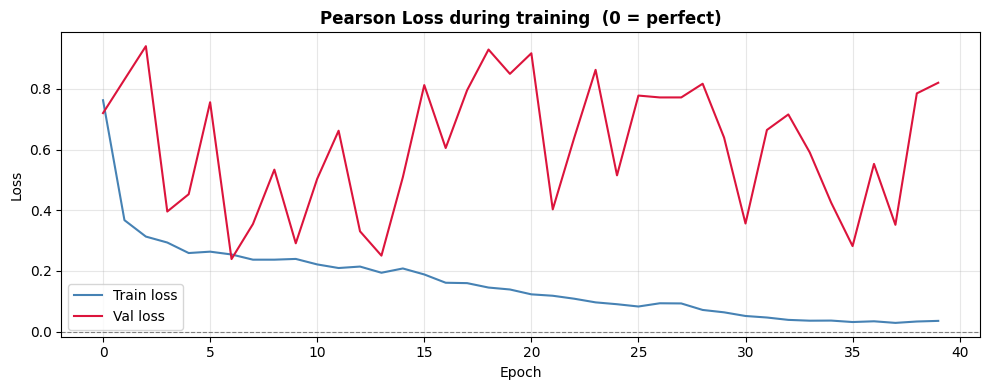

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train loss', color='steelblue')
plt.plot(val_losses,   label='Val loss',   color='crimson')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("Pearson Loss during training  (0 = perfect)", fontweight='bold')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/training_curves.png", dpi=150)
plt.show()

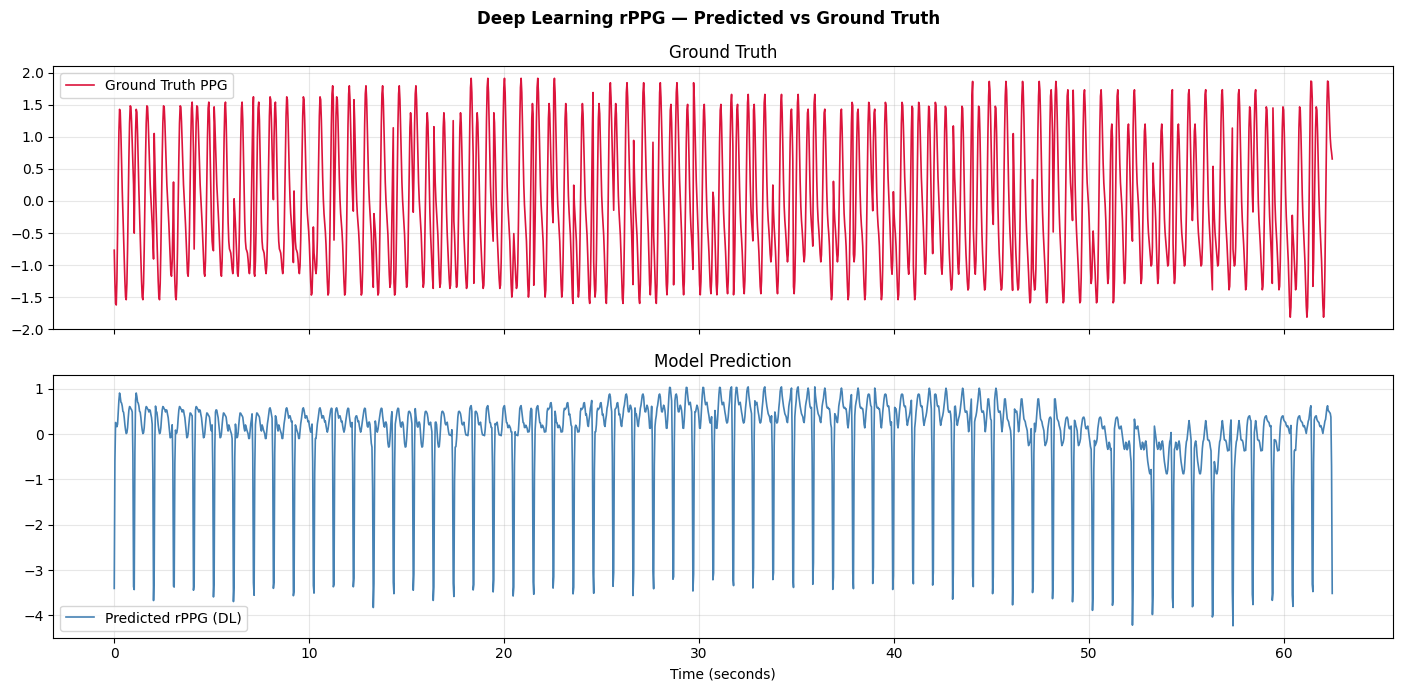

Pearson correlation (val): 0.1841


In [7]:
model.eval()
fps = 29.264106 
all_preds = []

with torch.no_grad():
    for xb, _ in val_loader:
        pred = model(xb.to(device)).cpu().numpy()
        all_preds.append(pred)

pred_signal = np.concatenate(all_preds, axis=0).flatten()
gt_signal   = y_val.flatten()
t_val       = np.arange(len(pred_signal)) / fps

# Normalize for display
pred_n = (pred_signal - pred_signal.mean()) / (pred_signal.std() + 1e-8)
gt_n   = (gt_signal   - gt_signal.mean())   / (gt_signal.std()   + 1e-8)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Deep Learning rPPG — Predicted vs Ground Truth", fontweight='bold')

axes[0].plot(t_val, gt_n,   color='crimson',   linewidth=1.2, label='Ground Truth PPG')
axes[0].set_title("Ground Truth"); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_val, pred_n, color='steelblue', linewidth=1.2, label='Predicted rPPG (DL)')
axes[1].set_title("Model Prediction"); axes[1].legend()
axes[1].set_xlabel("Time (seconds)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/dl_prediction.png", dpi=150)
plt.show()

# Pearson correlation as final metric
corr = np.corrcoef(pred_n, gt_n)[0,1]
print(f"Pearson correlation (val): {corr:.4f}")

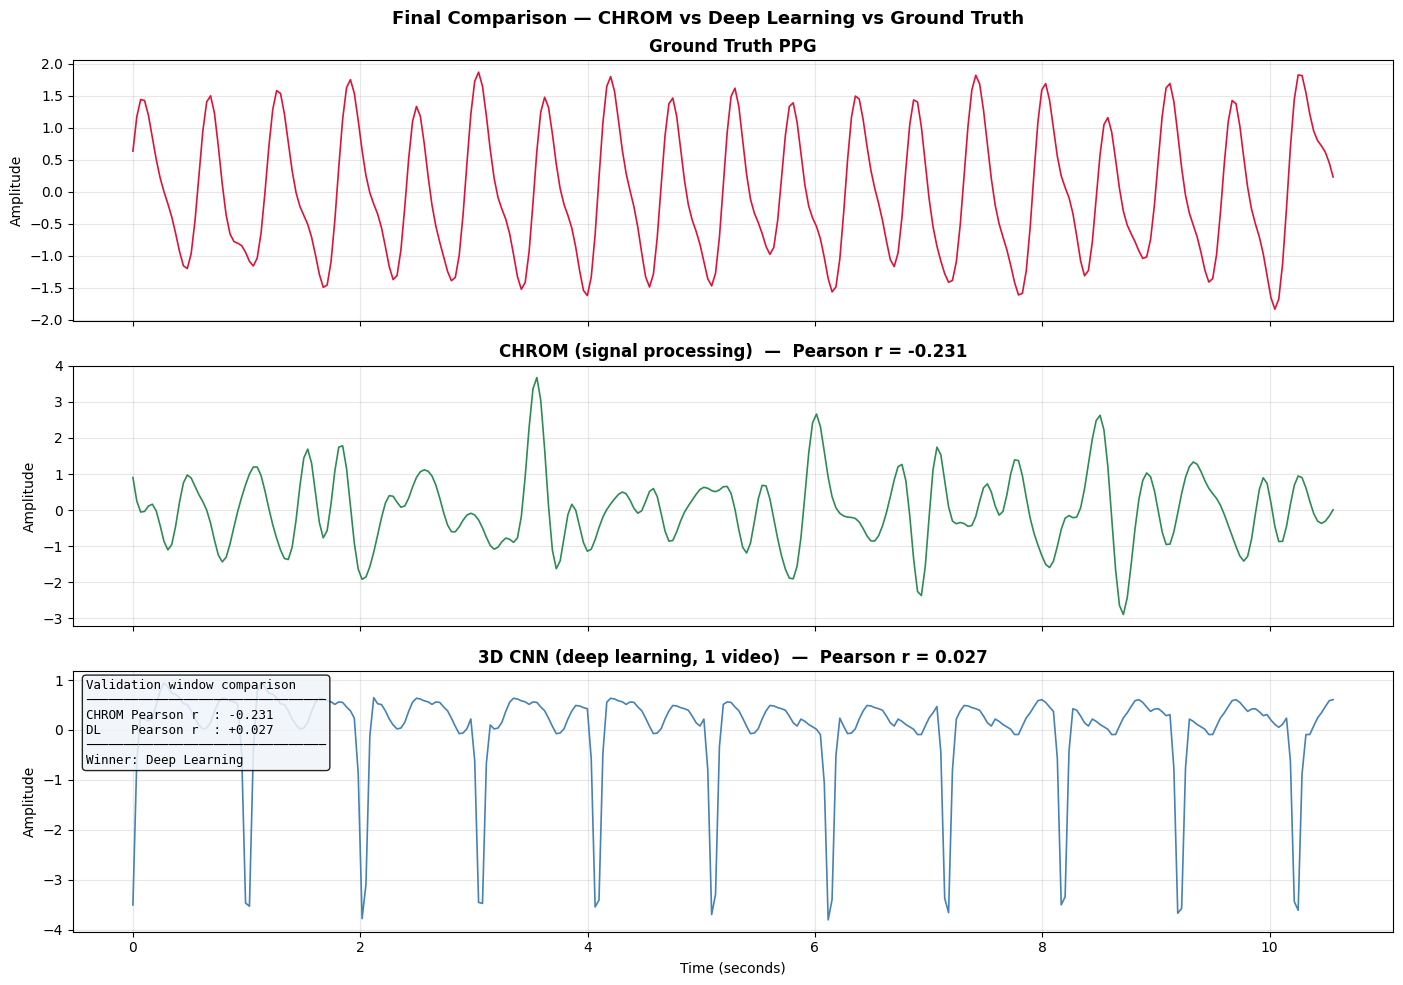

CHROM  Pearson r : -0.2315
DL     Pearson r : 0.0268


In [9]:
from scipy.signal import detrend, butter, filtfilt

def bandpass_filter(signal, lowcut=0.7, highcut=4.0, fs=29.264106, order=4):
    nyq  = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

def normalize(s):
    return (s - s.mean()) / (s.std() + 1e-8)

# Load CHROM rPPG signal (full length)
rppg_chrom = np.load("../outputs/rppg_signal.npy")

# Load ground truth
gt_data = np.loadtxt("../data/subject1/ground_truth.txt")
ppg_gt  = bandpass_filter(detrend(gt_data[0]))

# Get val portion of CHROM signal to match DL val window
val_start_frame = int(len(rppg_chrom) * 0.8)
chrom_val = rppg_chrom[val_start_frame:]
gt_val    = ppg_gt[val_start_frame : val_start_frame + len(pred_signal)]

# Trim all to same length
min_len   = min(len(chrom_val), len(pred_signal), len(gt_val))
chrom_val = normalize(chrom_val[:min_len])
dl_val    = normalize(pred_signal[:min_len])
gt_val    = normalize(gt_val[:min_len])
t_comp    = np.arange(min_len) / fps

# Pearson correlations
r_chrom = np.corrcoef(chrom_val, gt_val)[0,1]
r_dl    = np.corrcoef(dl_val,    gt_val)[0,1]

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Final Comparison — CHROM vs Deep Learning vs Ground Truth",
             fontsize=13, fontweight='bold')

axes[0].plot(t_comp, gt_val, color='crimson', linewidth=1.2)
axes[0].set_title("Ground Truth PPG", fontweight='bold')
axes[0].set_ylabel("Amplitude"); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_comp, chrom_val, color='seagreen', linewidth=1.2)
axes[1].set_title(f"CHROM (signal processing)  —  Pearson r = {r_chrom:.3f}",
                  fontweight='bold')
axes[1].set_ylabel("Amplitude"); axes[1].grid(True, alpha=0.3)

axes[2].plot(t_comp, dl_val, color='steelblue', linewidth=1.2)
axes[2].set_title(f"3D CNN (deep learning, 1 video)  —  Pearson r = {r_dl:.3f}",
                  fontweight='bold')
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Time (seconds)")
axes[2].grid(True, alpha=0.3)

# Summary box
props = dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.85)
summary = (
    f"Validation window comparison\n"
    f"{'─'*32}\n"
    f"CHROM Pearson r  : {r_chrom:+.3f}\n"
    f"DL    Pearson r  : {r_dl:+.3f}\n"
    f"{'─'*32}\n"
    f"Winner: {'CHROM' if r_chrom > r_dl else 'Deep Learning'}"
)
axes[2].text(0.01, 0.97, summary, transform=axes[2].transAxes,
             fontsize=9, verticalalignment='top',
             bbox=props, fontfamily='monospace')

plt.tight_layout()
plt.savefig("../outputs/chrom_vs_dl_final.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"CHROM  Pearson r : {r_chrom:.4f}")
print(f"DL     Pearson r : {r_dl:.4f}")